# Week 8 Machine Learning Homework

## Instructions
Complete all exercises below by writing code in the cells provided. Focus on implementing and understanding the sigmoid function and evaluation metrics.

---
Name: Sankirth Kalahasti

Net ID: sk11617

### Exercise 1: Sigmoid Function Implementation

Implement the sigmoid function from scratch and visualize it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Union

# Set style for cleaner plots
sns.set_theme(style="whitegrid")

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3603540250.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_values, y_values, label='Sigmoid $\sigma(x)$', color='blue', lw=2)


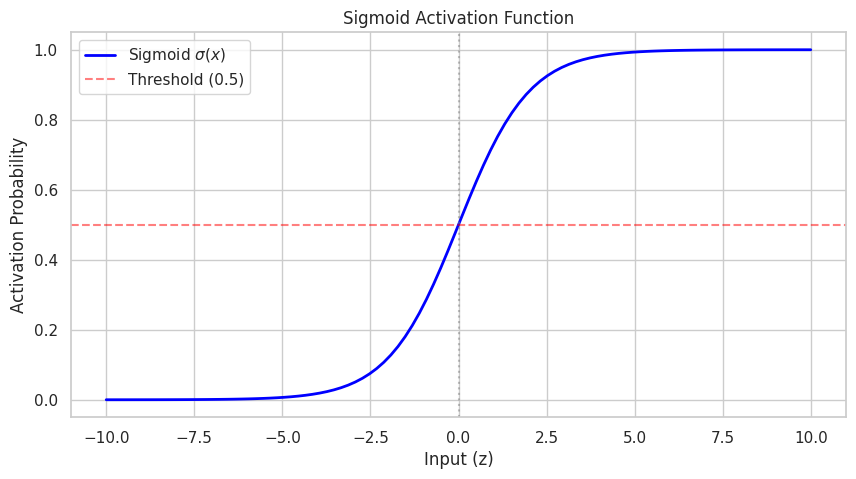

Sigmoid Test Results:
σ(-5) = 0.0067
σ(-2) = 0.1192
σ( 0) = 0.5000
σ( 2) = 0.8808
σ( 5) = 0.9933


In [2]:
def sigmoid(x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
    """
    Computes the sigmoid activation function.
    Formula: 1 / (1 + e^-x)
    """
    # np.exp handles both scalar floats and numpy arrays automatically
    return 1 / (1 + np.exp(-x))

def plot_sigmoid_curve(x_range: tuple = (-10, 10)):
    """Generates a visualization of the Sigmoid function."""
    x_values = np.linspace(x_range[0], x_range[1], 100)
    y_values = sigmoid(x_values)

    plt.figure(figsize=(10, 5))
    plt.plot(x_values, y_values, label='Sigmoid $\sigma(x)$', color='blue', lw=2)

    # Add visual guides
    plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Threshold (0.5)')
    plt.axvline(0, color='gray', linestyle=':', alpha=0.5)

    plt.title('Sigmoid Activation Function')
    plt.xlabel('Input (z)')
    plt.ylabel('Activation Probability')
    plt.legend()
    plt.show()

# --- Execution ---
plot_sigmoid_curve()

# Test cases
test_inputs = np.array([-5, -2, 0, 2, 5])
results = sigmoid(test_inputs)

print("Sigmoid Test Results:")
for x, y in zip(test_inputs, results):
    print(f"σ({x:2}) = {y:.4f}")

### Exercise 2: Logistic Regression Probability Calculation

Use the sigmoid function to calculate class probabilities.

In [3]:
def predict_logistic(features: list, coefs: list, bias: float, threshold: float = 0.5) -> Tuple[float, int]:
    """
    Calculates probability and class prediction using Logistic Regression logic.

    Returns:
        (probability, predicted_class)
    """
    # Convert to numpy arrays for vector math
    X = np.array(features)
    W = np.array(coefs)

    # 1. Calculate Linear Combination (Dot Product)
    z = np.dot(W, X) + bias

    # 2. Apply Activation Function
    probability = sigmoid(z)

    # 3. Apply Threshold
    prediction = 1 if probability >= threshold else 0

    return probability, prediction

# --- Execution ---
test_feat = [1.5, -0.8]
test_coef = [0.8, -0.3]
test_bias = 0.5

prob, pred = predict_logistic(test_feat, test_coef, test_bias)

print(f"\nLogistic Regression Prediction:")
print(f"Features: {test_feat}")
print(f"Probability: {prob:.4f}")
print(f"Class: {pred} (Threshold: 0.5)")


Logistic Regression Prediction:
Features: [1.5, -0.8]
Probability: 0.8744
Class: 1 (Threshold: 0.5)


### Exercise 3: Confusion Matrix Implementation

Implement a confusion matrix calculation from scratch.


Confusion Counts -> TP:4, TN:3, FP:2, FN:1


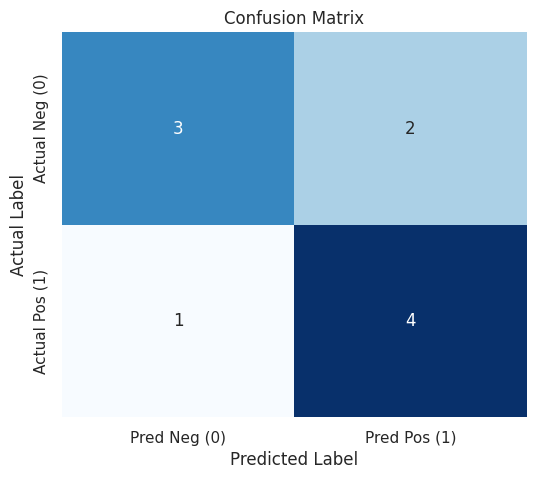

In [6]:
def compute_confusion_matrix(y_true: List[int], y_pred: List[int]) -> Tuple[int, int, int, int]:
    """
    Calculates TP, TN, FP, FN from scratch.
    """
    TP = TN = FP = FN = 0

    for t, p in zip(y_true, y_pred):
        if t == 1 and p == 1:
            TP += 1
        elif t == 0 and p == 0:
            TN += 1
        elif t == 0 and p == 1:
            FP += 1  # False Positive (Type I Error)
        elif t == 1 and p == 0:
            FN += 1  # False Negative (Type II Error)

    return TP, TN, FP, FN

def plot_confusion_matrix(TP, TN, FP, FN):
    """Visualizes the matrix using a Seaborn heatmap."""
    matrix = np.array([[TN, FP], [FN, TP]])

    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Neg (0)', 'Pred Pos (1)'],
                yticklabels=['Actual Neg (0)', 'Actual Pos (1)'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# --- Execution ---
y_true_sample = [0, 1, 0, 1, 1, 0, 1, 0, 0, 1]
y_pred_sample = [0, 1, 1, 1, 0, 0, 1, 0, 1, 1]

tp, tn, fp, fn = compute_confusion_matrix(y_true_sample, y_pred_sample)

print(f"\nConfusion Counts -> TP:{tp}, TN:{tn}, FP:{fp}, FN:{fn}")
plot_confusion_matrix(tp, tn, fp, fn)

### Exercise 4: Classification Metrics Calculation

Implement accuracy, precision, recall, and F1-score from scratch.


In [7]:
def calculate_metrics(TP: int, TN: int, FP: int, FN: int) -> dict:
    """
    Computes Accuracy, Precision, Recall, and F1.
    Returns a dictionary for easy access.
    """
    # 1. Accuracy: (TP + TN) / Total
    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0.0

    # 2. Precision: TP / (TP + FP)
    # How many selected items are relevant?
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

    # 3. Recall: TP / (TP + FN)
    # How many relevant items are selected?
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # 4. F1 Score: Harmonic Mean of Precision and Recall
    if (precision + recall) > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0.0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# --- Execution ---
metrics = calculate_metrics(tp, tn, fp, fn)

print("\nModel Evaluation:")
for metric, value in metrics.items():
    print(f"{metric:<10}: {value:.4f}")


Model Evaluation:
Accuracy  : 0.7000
Precision : 0.6667
Recall    : 0.8000
F1-Score  : 0.7273
